In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder
# 원핫 인코더
from sklearn.preprocessing import OneHotEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import optuna
from optuna.samplers import TPESampler # 데이터를 랜덤샘플링하기 위함
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING) # 수치가 떨어지면 경고로그가 뜨는데 그거를 막아줌

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습모델 ##################################################
#분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier

#회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge
from catboost import CatBoostRegressor

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 차원축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

# 연관규칙 학습
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 군집
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth

# 파이프라인
from sklearn.pipeline import Pipeline

# KDE를 그리기 위한 통계값을 구할 수 있는 함수
from scipy.stats import gaussian_kde

# 피어슨 상관 계수 (연속형 수치형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pearsonr
# 카이제곱 검증 (범주형 데이터 vs 범주현 데이터, 순위 x)
from scipy.stats import chi2_contingency
# 스피어만 상관계수 (범주형 데이터 vs 범주형 데이터, 순위 O)
from scipy.stats import spearmanr
# 포인트 이분 상관계수 (범주형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pointbiserialr

# 객체를 파일에 저장
import pickle

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### 데이터 불러오기

In [2]:
train_df = pd.read_csv('data/bike_sharing_train4.csv', index_col=0)
test_df = pd.read_csv('data/bike_sharing_test4.csv', index_col=0)

In [3]:
train_df

,temp,atemp,humidity,windspeed,log_count,year,log_windspeed,season_1,season_2,season_3,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,9.84,14.395,81,0.0000,2.833213,1,0.000000,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9.02,13.635,80,0.0000,3.713572,1,0.000000,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9.02,13.635,80,0.0000,3.496508,1,0.000000,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9.84,14.395,75,0.0000,2.639057,1,0.000000,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9.84,14.395,75,0.0000,0.693147,1,0.000000,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,15.58,19.695,50,26.0027,5.820083,0,3.295937,0,0,0,...,0,0,0,0,0,1,0,0,0,0
10882,14.76,17.425,57,15.0013,5.488938,0,2.772670,0,0,0,...,0,0,0,0,0,0,1,0,0,0
10883,13.94,15.910,61,15.0013,5.129899,0,2.772670,0,0,0,...,0,0,0,0,0,0,0,1,0,0
10884,13.94,17.425,61,6.0032,4.867534,0,1.946367,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [4]:
test_df

,temp,atemp,humidity,windspeed,year,log_windspeed,season_1,season_2,season_3,season_4,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,10.66,11.365,56,26.0027,1,3.295937,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10.66,13.635,56,0.0000,1,0.000000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,10.66,13.635,56,0.0000,1,0.000000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,10.66,12.880,56,11.0014,1,2.485023,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,10.66,12.880,56,11.0014,1,2.485023,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6488,10.66,12.880,60,11.0014,0,2.485023,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
6489,10.66,12.880,60,11.0014,0,2.485023,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
6490,10.66,12.880,60,11.0014,0,2.485023,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
6491,10.66,13.635,56,8.9981,0,2.302395,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0


### 분산선택
- 분산 변화가 거의 없는 컬럼들을 제거한다

In [5]:
# 분산이 0.01 보다 작은 데이터들을 찾는다
selector = VarianceThreshold(threshold=0.01)
selector.fit(train_df)

VarianceThreshold(threshold=0.01)

In [6]:
# 결과를 확인한다.
selected_df = train_df.iloc[:,selector.get_support()]
print(f'변환 후 피처 개수 : {selected_df.shape[1]}')
print(f'제거 된 피처 수 : {set(train_df.columns) - set(selected_df.columns)}')

변환 후 피처 개수 : 47
제거 된 피처 수 : set()


### 다중 공선성의 문제가 있는 컬럼을 제거한다.

In [7]:
# 결과 데이터를 제외한다.
temp_df = train_df.drop('log_count', axis=1)
# 상관계수 구하기
corr_matrix = temp_df.corr()
corr_matrix

,temp,atemp,humidity,windspeed,year,log_windspeed,season_1,season_2,season_3,season_4,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
temp,1.000000,0.984948,-0.064949,-0.017852,-0.061226,0.010252,-0.565655,0.192661,0.635975,-0.266220,...,0.078261,0.081880,0.077489,0.065038,0.050367,0.030436,0.013931,-0.000354,-0.012467,-0.023808
atemp,0.984948,1.000000,-0.043536,-0.057473,-0.058540,-0.027401,-0.569082,0.204421,0.607090,-0.245690,...,0.075487,0.078396,0.073191,0.060075,0.047119,0.029169,0.015231,0.001621,-0.010430,-0.021702
humidity,-0.064949,-0.043536,1.000000,-0.318607,0.078606,-0.242256,-0.166208,-0.031095,0.067308,0.129018,...,-0.146758,-0.150047,-0.145353,-0.124575,-0.100366,-0.059264,-0.027645,0.005666,0.029136,0.051748
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.015221,0.864504,0.128819,0.042991,-0.091521,-0.079535,...,0.076080,0.079278,0.085403,0.077874,0.063611,0.036765,0.007613,-0.019514,-0.024450,-0.044105
year,-0.061226,-0.058540,0.078606,0.015221,1.000000,-0.005168,-0.006315,0.002446,0.001598,0.002234,...,0.000807,0.000807,0.000807,0.000807,0.000807,0.000807,0.000807,0.000807,0.000807,0.000807
log_windspeed,0.010252,-0.027401,-0.242256,0.864504,-0.005168,1.000000,0.084283,0.048811,-0.051965,-0.080631,...,0.059416,0.054043,0.064935,0.056586,0.060039,0.043502,0.022882,-0.011379,-0.015305,-0.028539
season_1,-0.565655,-0.569082,-0.166208,0.128819,-0.006315,0.084283,1.000000,-0.331365,-0.331365,-0.331446,...,0.001582,0.001582,0.001582,0.001582,0.001582,0.001582,0.001582,0.001582,0.001582,0.001582
season_2,0.192661,0.204421,-0.031095,0.042991,0.002446,0.048811,-0.331365,1.000000,-0.335214,-0.335296,...,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509
season_3,0.635975,0.607090,0.067308,-0.091521,0.001598,-0.051965,-0.331365,-0.335214,1.000000,-0.335296,...,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509,-0.000509
season_4,-0.266220,-0.245690,0.129018,-0.079535,0.002234,-0.080631,-0.331446,-0.335296,-0.335296,1.000000,...,-0.000554,-0.000554,-0.000554,-0.000554,-0.000554,-0.000554,-0.000554,-0.000554,-0.000554,-0.000554


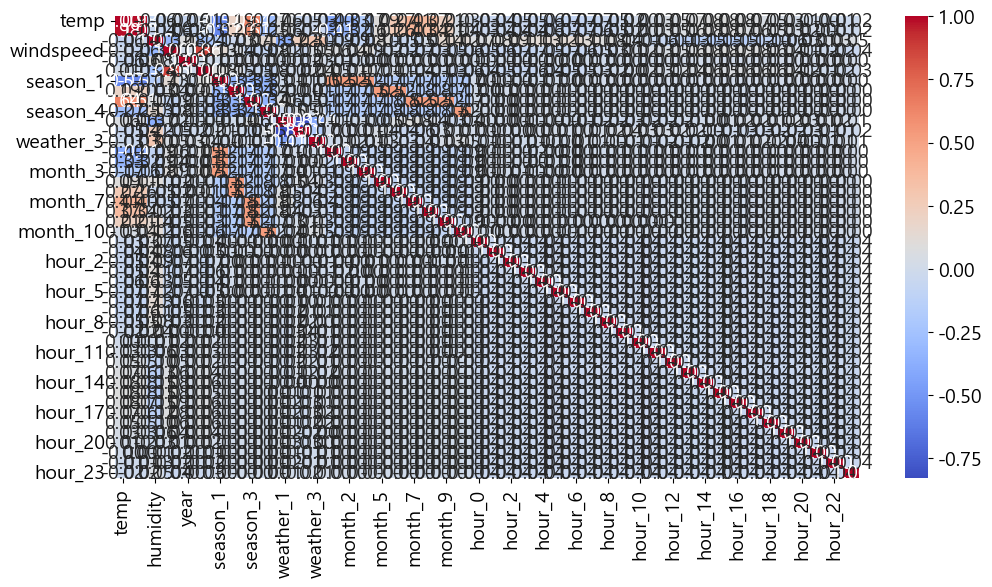

In [8]:
sns.heatmap(corr_matrix, annot=True,fmt='.2f', cmap='coolwarm', cbar=True)
plt.show()

In [9]:
# 상관계수가 0.7 이상ㅇ인 쌍을 찾는다
for i in range(len(corr_matrix.columns)) :
    for j in range(i) :
        if abs(corr_matrix.iloc[i,j]) > 0.7 :
            col_name = corr_matrix.columns[i]
            row_name = corr_matrix.columns[j]
            print(f'{row_name} - {col_name} : {corr_matrix.iloc[i,j]:.2f}')

temp - atemp : 0.98
windspeed - log_windspeed : 0.86
weather_1 - weather_2 : -0.83


In [10]:
# 컬럼을 제거한다.
a1 = ['atemp', 'windspeed', 'weather_2']
train_df.drop(a1, axis=1, inplace=True)
test_df.drop(a1, axis=1, inplace=True)

In [11]:
train_df.to_csv('data/bike_sharing_train5.csv',index=False)
test_df.to_csv('data/bike_sharing_test5.csv', index=False)